In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import math
from statsmodels.tsa.stattools import acf, pacf
from scipy.stats import ks_2samp
from statsmodels.tsa.stattools import kpss

# 0. Load data

In [2]:
sensor_hrv_df = pd.read_csv("data/sensor_hrv_filtered.csv")

print(f"Shape: {sensor_hrv_df.shape[0]} rows x {sensor_hrv_df.shape[1]} columns")
print(f"Number of unique deviceIds: {sensor_hrv_df['deviceId'].nunique()}")
print(f"Average records per deviceId: {sensor_hrv_df.shape[0] / sensor_hrv_df['deviceId'].nunique():.2f}")
sensor_hrv_df.head()

Shape: 38913 rows x 28 columns
Number of unique deviceIds: 49
Average records per deviceId: 794.14


,deviceId,ts_start,ts_end,missingness_score,HR,ibi,acc_x_avg,acc_y_avg,acc_z_avg,grv_x_avg,...,calories,light_avg,sdnn,sdsd,rmssd,pnn20,pnn50,lf,hf,lf/hf
0,ab60,1617262425031,1617262724833,0.295448,84.592816,728.534374,0.284765,-0.593973,9.195984,-0.094203,...,0.000000,841.324415,89.363225,78.033038,98.417649,0.746269,0.391791,1818.065625,1252.992443,1.450979
1,ab60,1616736817151,1616737116986,0.239085,78.589565,781.896913,3.050179,-1.239353,5.790543,-0.211973,...,0.085083,486.485050,100.804974,73.468687,106.602933,0.803704,0.540741,1918.499169,2784.393293,0.689019
2,ab60,1616736517083,1616736816952,0.100773,75.620524,812.183910,2.153267,-3.546833,8.499866,-0.628970,...,NaN,779.033113,89.073518,48.675496,74.504896,0.809816,0.484663,1292.696555,1034.550027,1.249525
3,ab60,1616736217077,1616736516883,0.268178,85.813165,769.754943,2.898409,-3.401356,4.606113,-0.249247,...,1.375000,389.408638,102.371770,48.631219,70.615187,0.719178,0.400685,1561.785747,812.118619,1.923101
4,ab60,1616734416800,1616734716672,0.043466,76.944500,775.190053,-0.050221,-6.576164,5.377019,0.715893,...,0.000000,276.345515,84.045665,42.104491,66.973170,0.736111,0.450000,3460.217895,1886.157661,1.834533


### 0.1. Plot all entries for a specific device

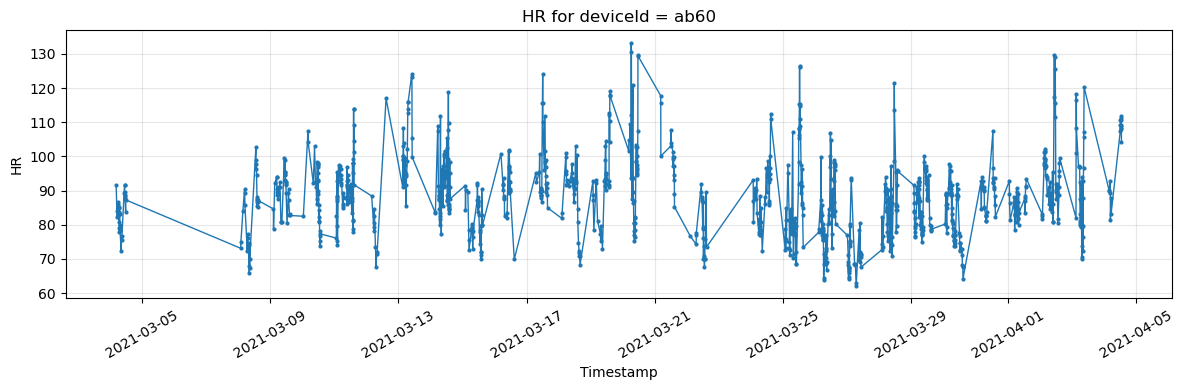

In [3]:
ab60_df = sensor_hrv_df[sensor_hrv_df["deviceId"] == "ab60"].copy()

ab60_df = ab60_df.sort_values("ts_start")
ab60_df["datetime"] = pd.to_datetime(ab60_df["ts_start"], unit="ms", errors="coerce")
x = ab60_df["datetime"] # we use ts_start as timestamp for the x-axis
xlabel = "Timestamp"

y = pd.to_numeric(ab60_df["HR"], errors="coerce")

plt.figure(figsize=(12, 4))
plt.plot(x, y, marker="o", markersize=2, linewidth=1)
plt.title("HR for deviceId = ab60")
plt.xlabel(xlabel)
plt.ylabel("HR")
plt.xticks(rotation=30)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 0.2 Plot all entries for a specific device and day

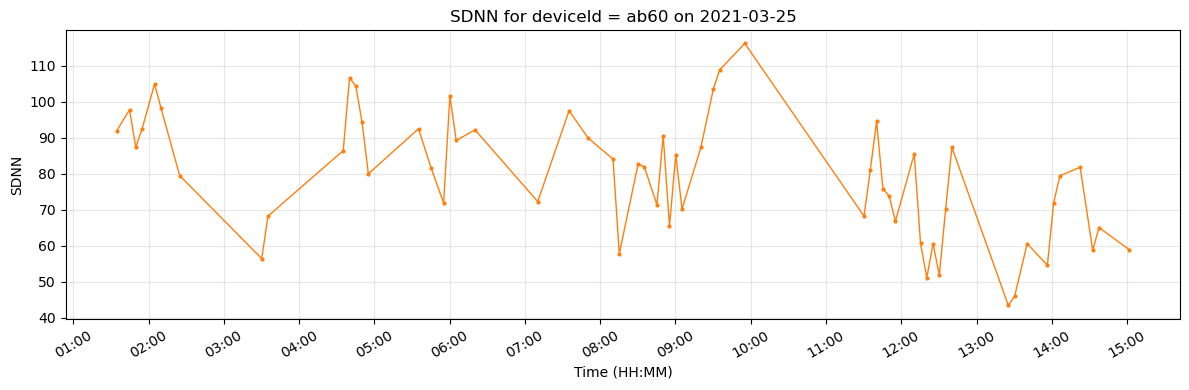

In [4]:
specific_day = "2021-03-25"

# SDNN plot for the same day and device
ab60_sdnn_day_df = sensor_hrv_df[sensor_hrv_df["deviceId"] == "ab60"].copy()
ab60_sdnn_day_df["datetime"] = pd.to_datetime(ab60_sdnn_day_df["ts_start"], unit="ms", errors="coerce")

same_day_mask = ab60_sdnn_day_df["datetime"].dt.strftime("%Y-%m-%d") == specific_day
ab60_sdnn_day_df = ab60_sdnn_day_df[same_day_mask].sort_values("datetime")

if ab60_sdnn_day_df.empty:
    print(f"No SDNN data for deviceId='ab60' on {specific_day}")
else:
    x_sdnn = ab60_sdnn_day_df["datetime"]
    y_sdnn = pd.to_numeric(ab60_sdnn_day_df["sdnn"], errors="coerce")

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(x_sdnn, y_sdnn, marker="o", markersize=2, linewidth=1, color="tab:orange")
    ax.set_title(f"SDNN for deviceId = ab60 on {specific_day}")
    ax.set_xlabel("Time (HH:MM)")
    ax.set_ylabel("SDNN")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
    ax.xaxis.set_major_locator(mdates.HourLocator(interval=1))
    plt.xticks(rotation=30)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

# 1. Memory
The current state of a complex system depends on previous states at any time delay.

### 1.1. Dependency on past values
Statistically, it means the time series is not random. Therefore, we test for Bartels rank test.

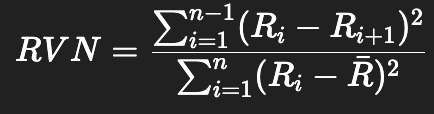{width=200}
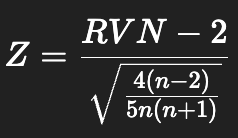{width=130}

In [5]:
def bartels_rank_test(series, alpha=0.02):
    """Perform Bartels Rank Test for randomness on a given pandas Series."""

    # Rank data
    ranks = series.rank(method="average")
    n = len(series)

    # Compute RVN (Rank Variace Normalized: how jugged the ranks are)
    diff = np.diff(ranks)
    num = np.sum(diff**2)
    mean_rank = (n + 1) / 2
    denom = np.sum((ranks - mean_rank)**2)
    rvn = num / denom

    # Compute z-score (how unsual the RVN is compared to what we would expect under randomness)
    expected_rvn = 2.0 # expected value of RVN under randomness
    var_rvn = (4 * (n - 2) * (5 * n**2 - 2 * n - 9)) / (5 * n * (n + 1) * (n - 1) ** 2)
    z = (rvn - expected_rvn) / math.sqrt(var_rvn)

    # Compute p-value from z-score (statistical significance of the result)
    def normal_cdf(value):
        return 0.5 * (1 + math.erf(value / math.sqrt(2)))
    p_value = 2 * (1 - normal_cdf(abs(z)))

    decision = "reject_H0" if p_value < alpha else "fail_to_reject_H0"

    return {
        "n": n,
        "rvn": rvn,
        "z": z,
        "p_value": p_value,
        "decision": decision,
    }

In [6]:
# Compute Bartels test for HR, SDNN, and RMSSD for each deviceId
metrics = ["HR", "sdnn", "rmssd"]
results_by_metric = {m: [] for m in metrics}

for device_id, grp in sensor_hrv_df.groupby("deviceId", dropna=True):
    grp_sorted = grp.sort_values("ts_start")

    for metric in metrics:
        result = bartels_rank_test(grp_sorted[metric])
        result["deviceId"] = device_id
        results_by_metric[metric].append(result)

# Display results for each metric
for metric in metrics:
    metric_df = (
        pd.DataFrame(results_by_metric[metric])[["deviceId", "n", "rvn", "z", "p_value", "decision"]]
        .sort_values(["p_value", "deviceId"], na_position="last")
        .reset_index(drop=True)
    )
    print(f"{metric} Bartels test (top 5):")
    display(metric_df.head(5))
    
    # Percentage of devices that reject H0 for this metric
    reject_count = (metric_df["decision"] == "reject_H0").sum()
    total_count = metric_df.shape[0]
    print(f"  Reject H0: {reject_count}/{total_count} devices ({reject_count / total_count:.1%})\n")

HR Bartels test (top 5):


,deviceId,n,rvn,z,p_value,decision
0,ab60,1103,0.461552,-25.563277,0.0,reject_H0
1,am77,285,0.748103,-10.593365,0.0,reject_H0
2,av54,415,0.711481,-13.146809,0.0,reject_H0
3,ba30,1045,0.642065,-21.963342,0.0,reject_H0
4,bp16,528,0.431336,-18.046560,0.0,reject_H0


  Reject H0: 49/49 devices (100.0%)

sdnn Bartels test (top 5):


,deviceId,n,rvn,z,p_value,decision
0,ab60,1103,1.210187,-13.123756,0.0,reject_H0
1,ba30,1045,1.177200,-13.308026,0.0,reject_H0
2,ea80,288,0.762864,-10.523142,0.0,reject_H0
3,gd81,1265,1.367736,-11.250046,0.0,reject_H0
4,hk52,1010,1.427083,-9.110113,0.0,reject_H0


  Reject H0: 47/49 devices (95.9%)

rmssd Bartels test (top 5):


,deviceId,n,rvn,z,p_value,decision
0,ab60,1103,1.381071,-10.284296,0.0,reject_H0
1,ba30,1045,1.087697,-14.755664,0.0,reject_H0
2,ea80,288,0.714999,-10.930286,0.0,reject_H0
3,gd81,1265,1.493742,-9.007980,0.0,reject_H0
4,hk52,1010,1.365982,-10.081694,0.0,reject_H0


  Reject H0: 47/49 devices (95.9%)



### 1.2 Long range temporal correlation
Long term memory is assesed by visually inspecting the autocorrelation function (ACF) for each item.
To summarize presence of long term memory, we use the partial autocorrelation function (PACF), which isoltes direct relationship of a specific lag.

In [7]:
def compute_acf_pacf_by_device(dataframe, metric, plot_max_lag=300, pacf_max_lag_target=300, alpha_z=1.96, pacf_lag_gt=100):
    """Compute ACF/PACF summaries for a metric across all deviceId groups."""
    acf_results = {}
    pacf_summary_rows = []

    for device_id, grp in dataframe.groupby("deviceId", dropna=True):
        series = (
            grp.sort_values("ts_start")[metric]
            .pipe(pd.to_numeric, errors="coerce")
            .dropna()
            .reset_index(drop=True)
        )
        n = len(series)
        if n < 3:
            pacf_summary_rows.append(
                {
                    "deviceId": device_id,
                    "n": n,
                    "pacf_max_lag_used": np.nan,
                    "num_significant_pacf_lags": np.nan,
                    "max_significant_pacf_lag": np.nan,
                    "has_significant_pacf_lag_gt_threshold": False,
                    "significance_threshold": np.nan,
                }
            )
            continue

        nlags_acf = min(plot_max_lag, n - 1)
        acf_vals = acf(series, nlags=nlags_acf, fft=True)
        acf_results[device_id] = {
            "n": n,
            "lags": np.arange(nlags_acf + 1),
            "acf": acf_vals,
        }

        nlags_pacf = min(pacf_max_lag_target, n - 1, max(1, n // 2 - 1))
        pacf_vals = pacf(series, nlags=nlags_pacf, method="ywm")

        threshold = alpha_z / np.sqrt(n)
        sig_mask = np.abs(pacf_vals[1:]) > threshold
        sig_lags = np.where(sig_mask)[0] + 1

        pacf_summary_rows.append(
            {
                "deviceId": device_id,
                "n": n,
                "pacf_max_lag_used": nlags_pacf,
                "num_significant_pacf_lags": int(sig_mask.sum()),
                "max_significant_pacf_lag": int(sig_lags.max()) if len(sig_lags) else np.nan,
                "has_significant_pacf_lag_gt_threshold": bool((sig_lags > pacf_lag_gt).any()),
                "significance_threshold": threshold,
            }
        )

    pacf_by_device_df = (
        pd.DataFrame(pacf_summary_rows)
        .sort_values(["num_significant_pacf_lags", "deviceId"], ascending=[False, True], na_position="last")
        .reset_index(drop=True)
    )

    return acf_results, pacf_by_device_df


def plot_acf_grid(acf_results, metric, ncols=4):
    """Plot ACF results in a grid of subplots."""
    sorted_devices = sorted(acf_results.keys())
    n_devices = len(sorted_devices)
    nrows = int(np.ceil(n_devices / ncols)) if n_devices > 0 else 1

    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 2.8 * nrows), squeeze=False)

    for i, device_id in enumerate(sorted_devices):
        r = i // ncols
        c = i % ncols
        ax = axes[r, c]

        d = acf_results[device_id]
        lags = d["lags"]
        vals = d["acf"]
        n = d["n"]
        conf = 1.96 / np.sqrt(n)

        markerline, stemlines, baseline = ax.stem(lags, vals, linefmt="C0-", markerfmt="C0o", basefmt="k-")
        plt.setp(markerline, markersize=2)
        plt.setp(stemlines, linewidth=0.6)
        plt.setp(baseline, linewidth=0.6)

        ax.axhline(0, color="black", linewidth=0.6)
        ax.axhline(conf, color="red", linestyle="--", linewidth=0.6)
        ax.axhline(-conf, color="red", linestyle="--", linewidth=0.6)
        ax.set_title(f"{device_id} (n={n})", fontsize=9)
        ax.set_xlabel("Lag")
        ax.set_ylabel("ACF")
        ax.set_ylim(-1, 1)

    for j in range(n_devices, nrows * ncols):
        r = j // ncols
        c = j % ncols
        axes[r, c].axis("off")

    fig.suptitle(f"{metric} autocorrelation function (ACF) by deviceId", y=1.01, fontsize=14)
    plt.tight_layout()
    plt.show()

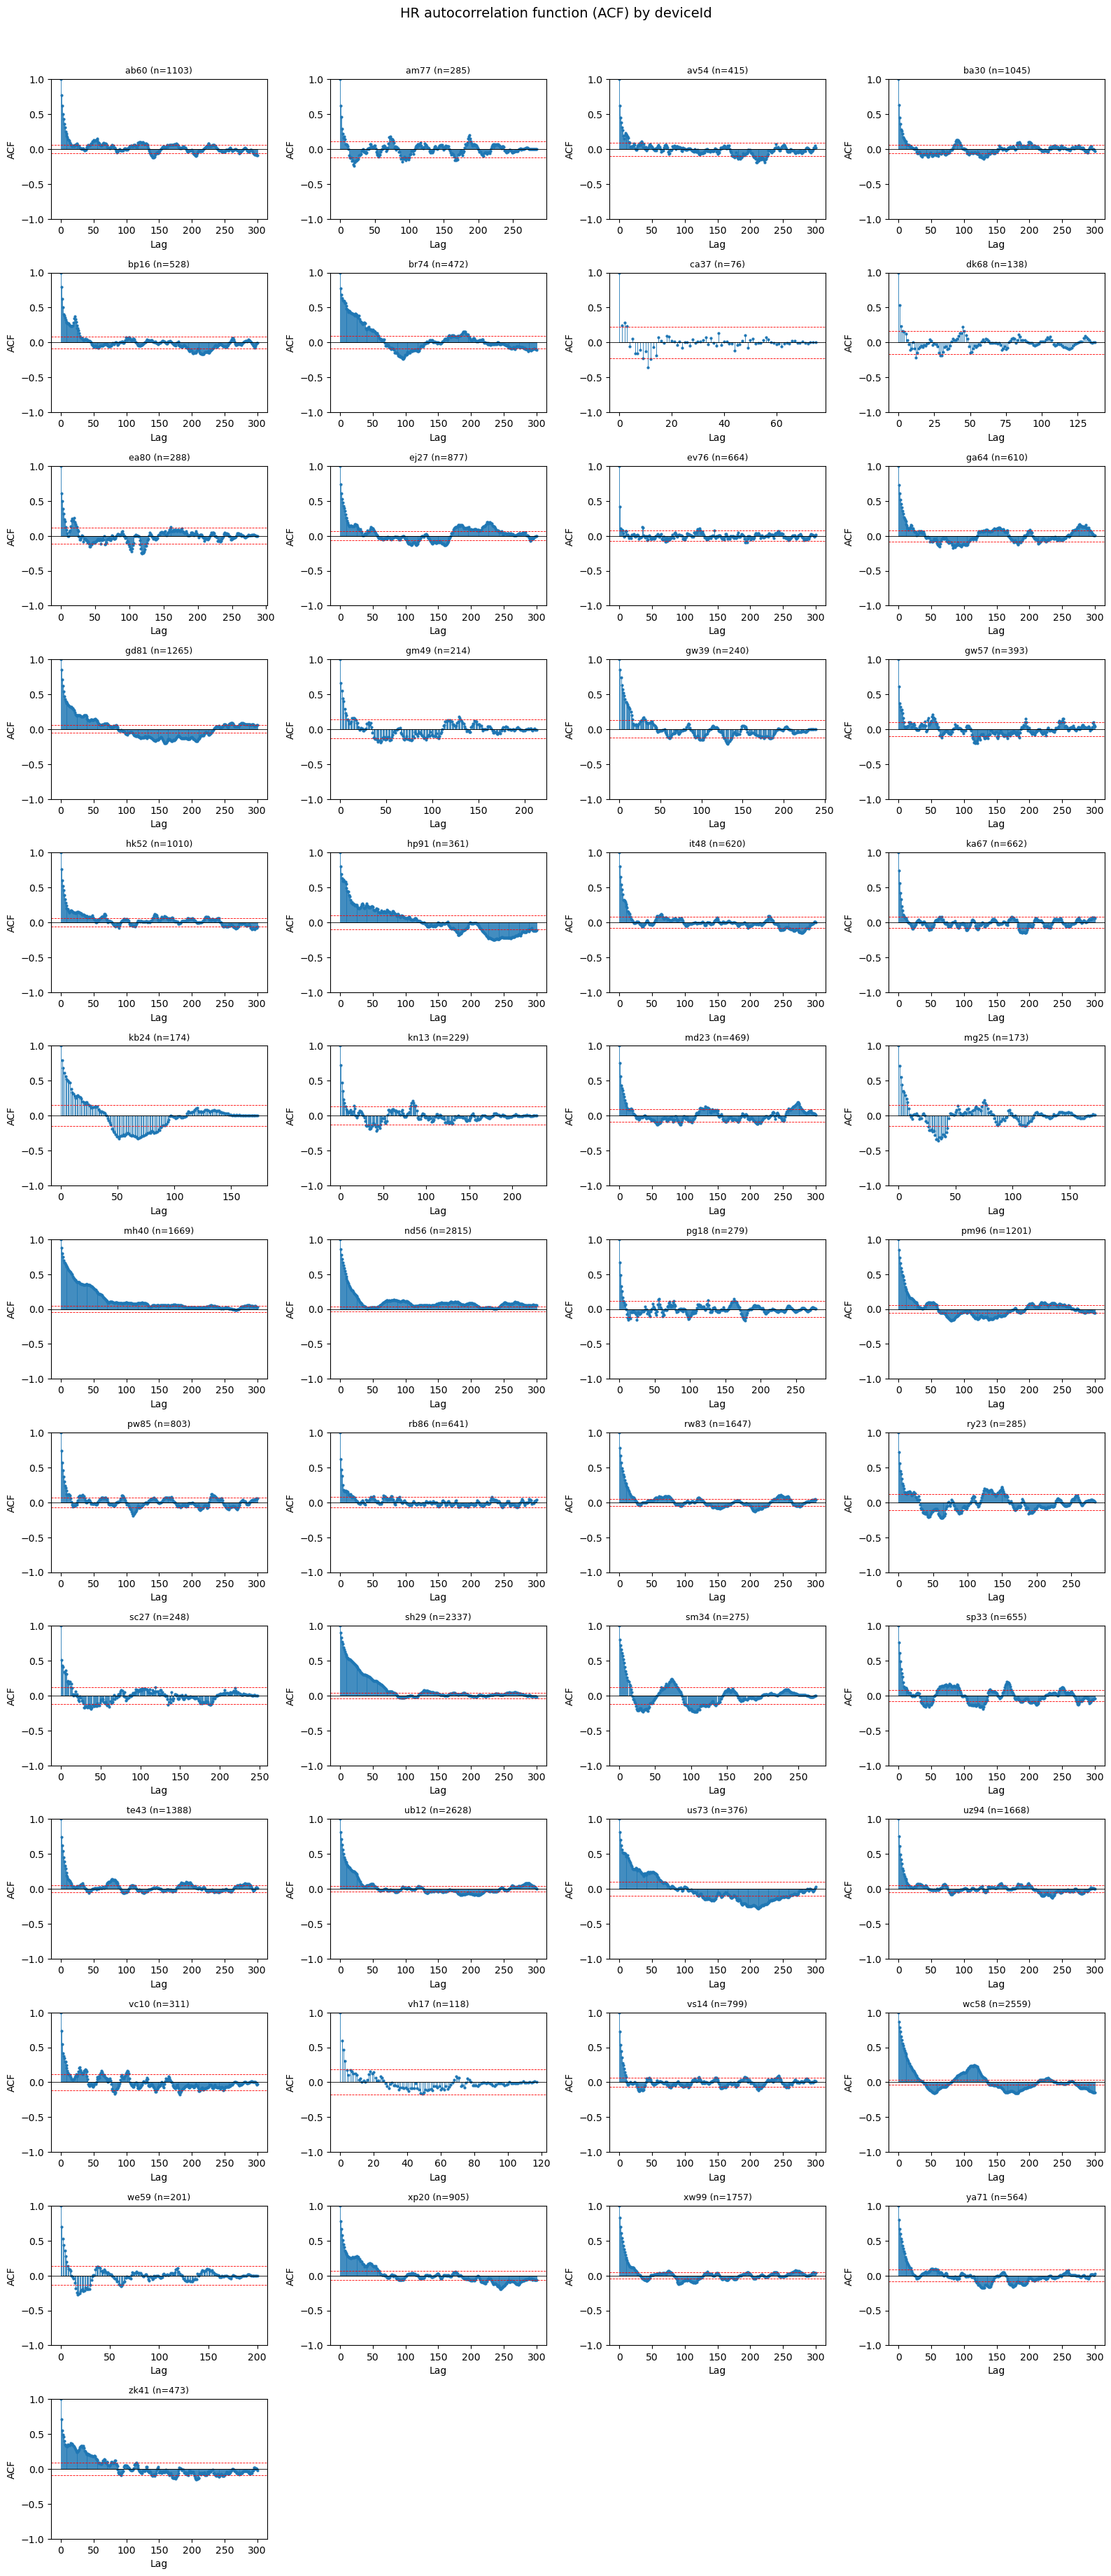

PACF summary by deviceId (HR) (top 5):


,deviceId,n,pacf_max_lag_used,num_significant_pacf_lags,max_significant_pacf_lag,has_significant_pacf_lag_gt_threshold,significance_threshold
0,wc58,2559,300,20,245,True,0.038745
1,nd56,2815,300,16,199,True,0.036942
2,gd81,1265,300,14,272,True,0.055108
3,hk52,1010,300,14,277,True,0.061673
4,ka67,662,300,13,222,True,0.076178


Devices with at least one significant PACF lag > 100: 34 / 49


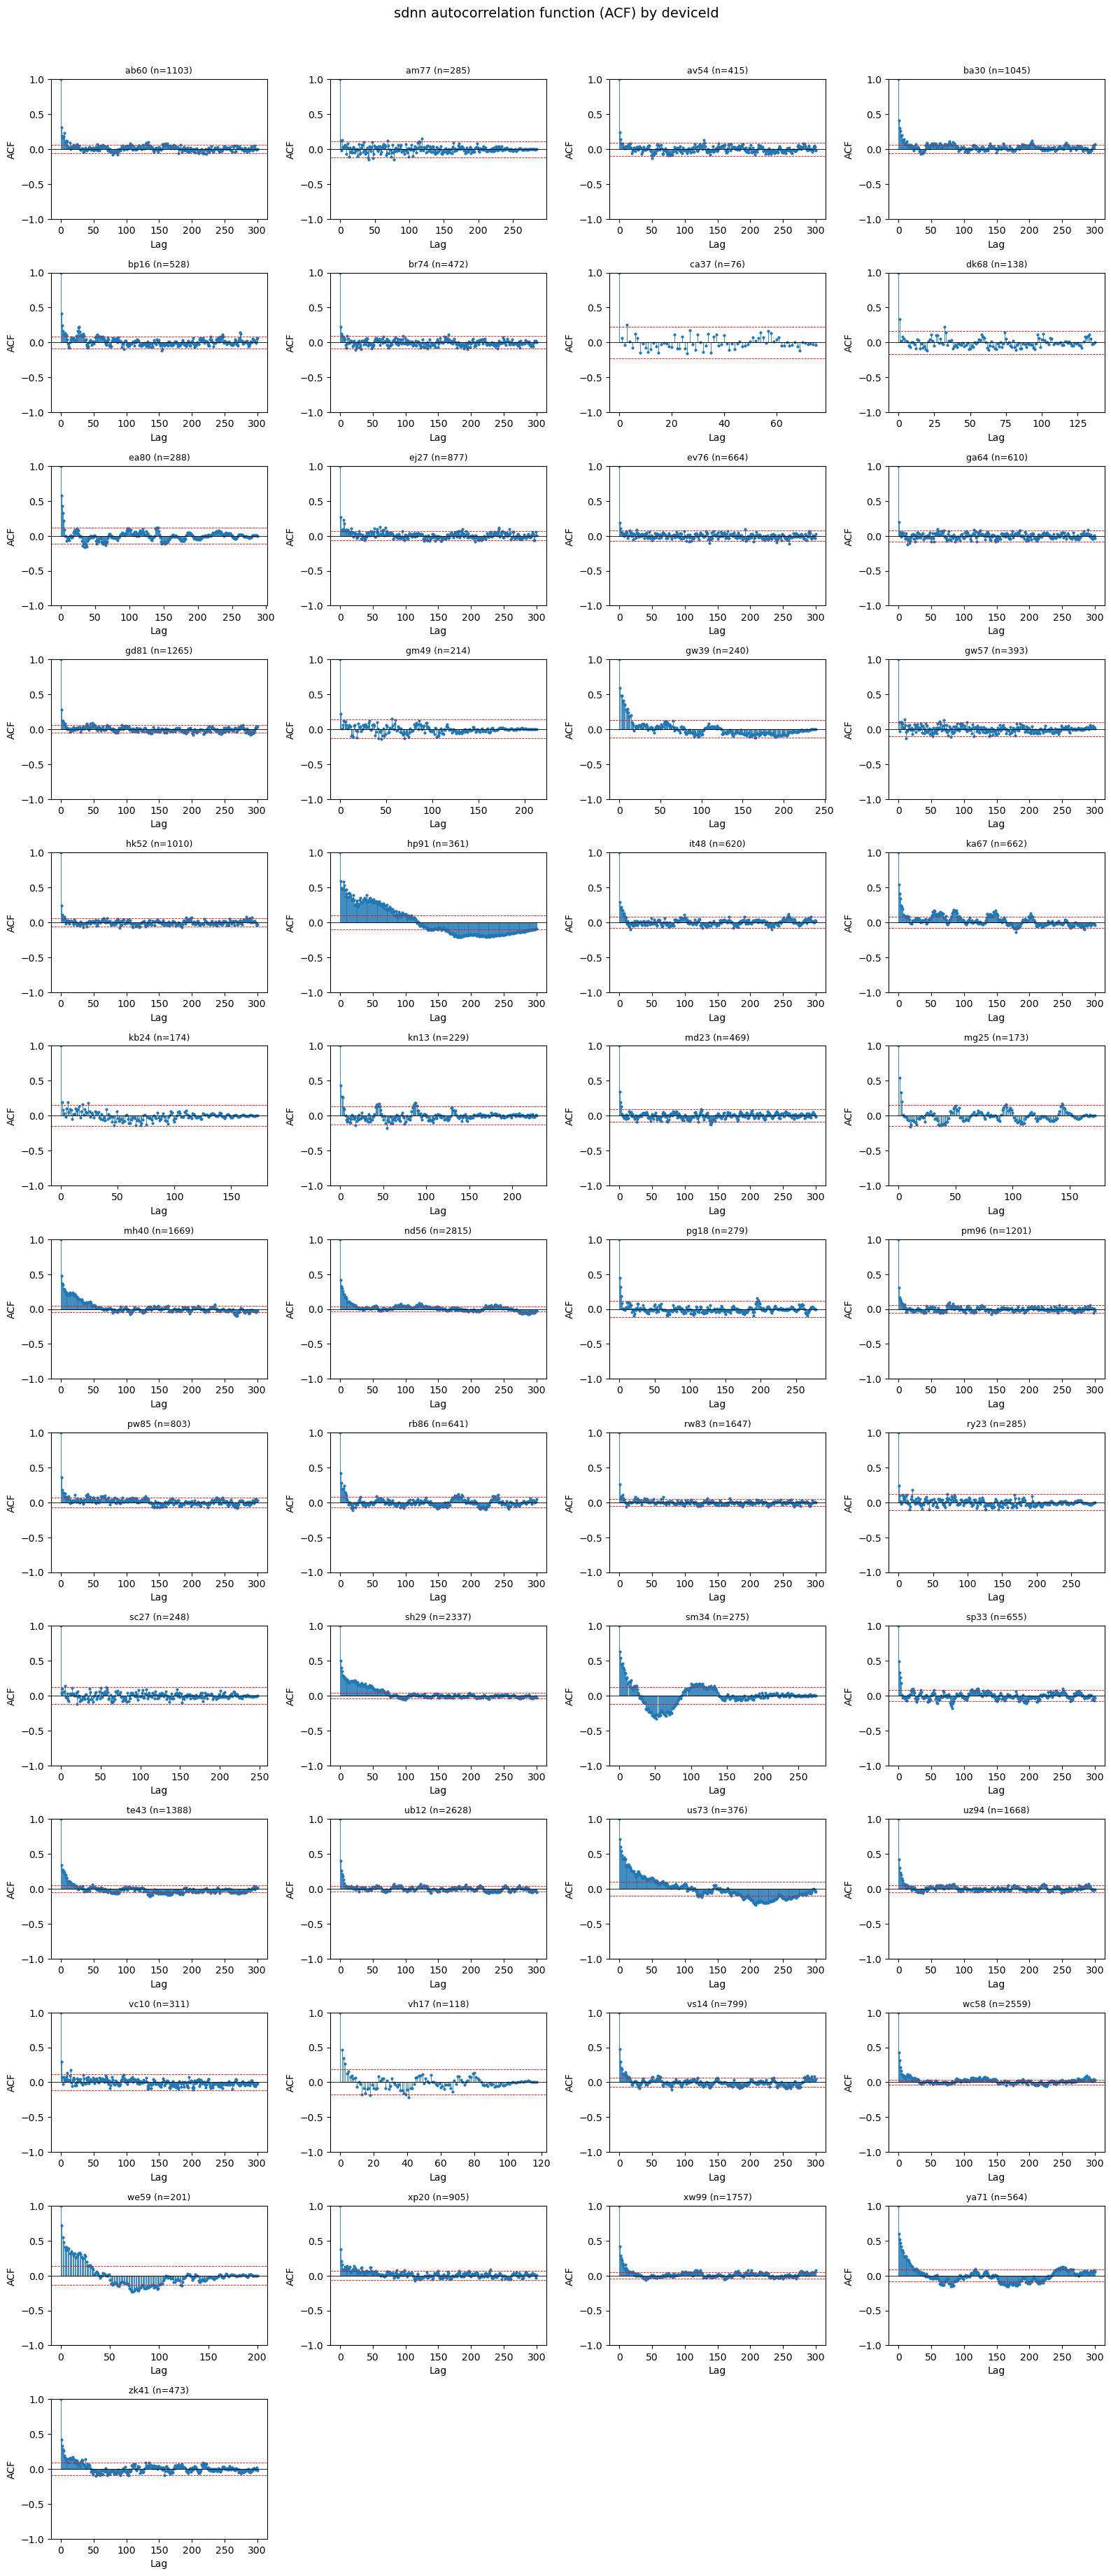

PACF summary by deviceId (sdnn) (top 5):


,deviceId,n,pacf_max_lag_used,num_significant_pacf_lags,max_significant_pacf_lag,has_significant_pacf_lag_gt_threshold,significance_threshold
0,sh29,2337,300,30,228,True,0.040544
1,ub12,2628,300,26,288,True,0.038233
2,mh40,1669,300,24,280,True,0.047976
3,ej27,877,300,22,282,True,0.066184
4,wc58,2559,300,20,284,True,0.038745


Devices with at least one significant PACF lag > 100: 30 / 49


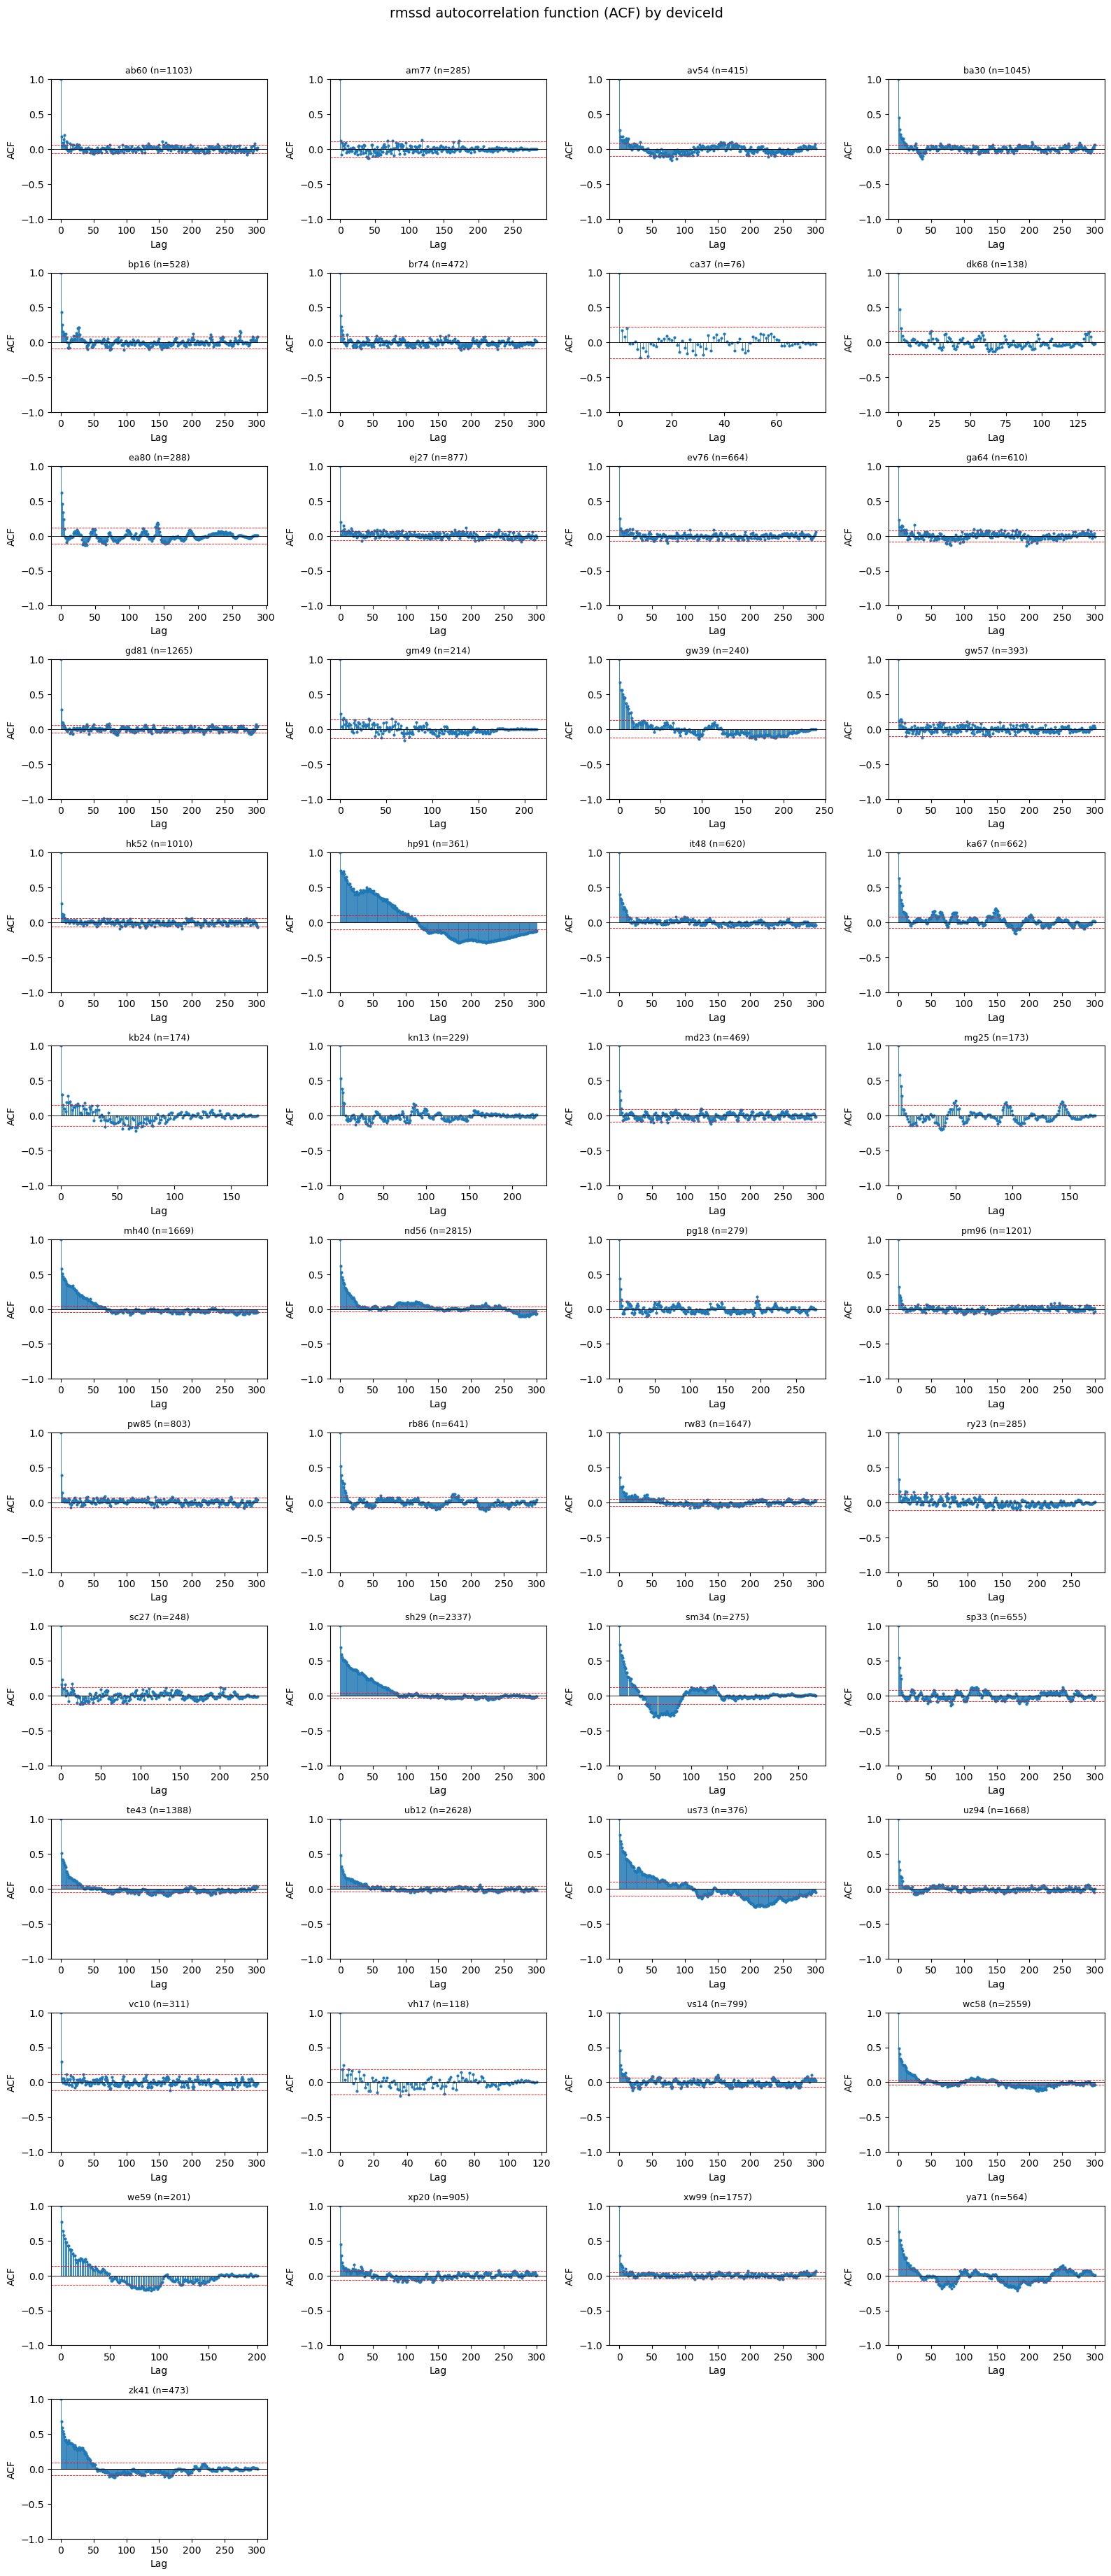

PACF summary by deviceId (rmssd) (top 5):


,deviceId,n,pacf_max_lag_used,num_significant_pacf_lags,max_significant_pacf_lag,has_significant_pacf_lag_gt_threshold,significance_threshold
0,mh40,1669,300,21,282.0,True,0.047976
1,sh29,2337,300,21,225.0,True,0.040544
2,rw83,1647,300,20,285.0,True,0.048296
3,ub12,2628,300,20,277.0,True,0.038233
4,nd56,2815,300,18,290.0,True,0.036942


Devices with at least one significant PACF lag > 100: 33 / 49


In [8]:
metrics = ["HR", "sdnn", "rmssd"]

for metric in metrics:
    acf_results, pacf_by_device_df = compute_acf_pacf_by_device(
        sensor_hrv_df,
        metric=metric,
        plot_max_lag=300,
        pacf_max_lag_target=300,
        alpha_z=1.96,
        pacf_lag_gt=100,
    )

    plot_acf_grid(acf_results, metric)

    print(f"PACF summary by deviceId ({metric}) (top 5):")
    display(pacf_by_device_df.head(5))
    print(
        "Devices with at least one significant PACF lag > 100:",
        int(pacf_by_device_df["has_significant_pacf_lag_gt_threshold"].sum()),
        "/", int(pacf_by_device_df["deviceId"].nunique())
    )


# 2. Regime shifts

Assess regime shifts via:
1. **KPSS test** (null hyp: stationarity around a level; alternative hyp: unit-root/non-stationary).
2. **Distributional change points** using a divisive, permutation-tested procedure (e-divisive-like) to detect significant shifts in data distribution.

We run both analyses for the **full period** and a **baseline period** (first `baseline_n` observations) for each device and metric.

In [ ]:
def kpss_level_test(series, alpha=0.05):
    stat, p_value, _, _ = kpss(series, regreseriession="c", nlags="auto")
    return {
        "n": len(series),
        "kpss_stat": float(stat),
        "kpss_p": float(p_value),
        "reject_stationarity": bool(p_value < alpha),
    }

def _best_split_ks(x, start, end, min_size=30, step=5):
    best_t, best_stat = None, -np.inf
    for t in range(start + min_size, end - min_size + 1, step):
        left = x[start:t]
        right = x[t:end]
        if len(left) < min_size or len(right) < min_size:
            continue
        stat = ks_2samp(left, right, mode="asymp").statistic
        if stat > best_stat:
            best_stat = stat
            best_t = t
    return best_t, best_stat


def _perm_pvalue_for_split(x, start, end, split_t, observed_stat, n_perm=120, rng=None):
    if rng is None:
        rng = np.random.default_rng(42)

    segment = x[start:end]
    n1 = split_t - start
    if n1 <= 0 or n1 >= len(segment):
        return np.nan

    ge = 0
    for _ in range(n_perm):
        perm = rng.permutation(segment)
        stat_perm = ks_2samp(perm[:n1], perm[n1:], mode="asymp").statistic
        if stat_perm >= observed_stat:
            ge += 1

    return (ge + 1) / (n_perm + 1)


def divisive_change_points(series, alpha=0.05, min_size=30, n_perm=120, step=5, max_cps=8, seed=42):
    """Divisive, permutation-tested change-point detection (e-divisive-like)."""
    x = pd.to_numeric(series, errors="coerce").dropna().to_numpy()
    n = len(x)
    if n < 2 * min_size + 1:
        return []

    rng = np.random.default_rng(seed)
    cps = []

    def recurse(start, end):
        if len(cps) >= max_cps:
            return
        if end - start < 2 * min_size + 1:
            return

        split_t, obs_stat = _best_split_ks(x, start, end, min_size=min_size, step=step)
        if split_t is None:
            return

        p_value = _perm_pvalue_for_split(
            x,
            start,
            end,
            split_t,
            obs_stat,
            n_perm=n_perm,
            rng=rng,
        )

        if np.isnan(p_value) or p_value >= alpha:
            return

        cps.append(split_t)
        recurse(start, split_t)
        recurse(split_t, end)

    recurse(0, n)
    return sorted(cps)


def plot_regime_shifts(series, cps, title):
    s = pd.to_numeric(series, errors="coerce").dropna().reset_index(drop=True)
    plt.figure(figsize=(12, 3.8))
    plt.plot(s.index, s.values, linewidth=1)
    for cp in cps:
        plt.axvline(cp, color="red", linestyle="--", linewidth=1)
    plt.title(title)
    plt.xlabel("Time index")
    plt.ylabel("Value")
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

Regime-shift summary (HR)


,deviceId,n_full,kpss_full_p,kpss_full_reject_stationarity,n_regime_shifts_full,n_baseline,kpss_baseline_p,kpss_baseline_reject_stationarity,n_regime_shifts_baseline
24,mh40,1669,0.010000,True,8,492,0.010000,True,6
25,nd56,2815,0.010000,True,8,492,0.100000,False,6
33,sh29,2337,0.010000,True,8,492,0.010000,True,6
36,te43,1388,0.010000,True,8,492,0.100000,False,6
48,zk41,473,0.010000,True,8,473,0.010000,True,6
9,ej27,877,0.015061,True,8,492,0.100000,False,6
4,bp16,528,0.024762,True,8,492,0.023181,True,6
2,av54,415,0.039534,True,8,415,0.039534,True,6
45,xp20,905,0.051647,False,8,492,0.100000,False,6
16,hk52,1010,0.054788,False,8,492,0.017835,True,6


KPSS non-stationary (full): 15 / 49
KPSS non-stationary (baseline): 17 / 49
Mean # regime shifts (full): 6.18
Mean # regime shifts (baseline): 5.10

Regime-shift summary (sdnn)


,deviceId,n_full,kpss_full_p,kpss_full_reject_stationarity,n_regime_shifts_full,n_baseline,kpss_baseline_p,kpss_baseline_reject_stationarity,n_regime_shifts_baseline
94,xp20,905,0.010000,True,8,492,0.048527,True,6
49,ab60,1103,0.017573,True,8,492,0.100000,False,6
96,ya71,564,0.080062,False,8,492,0.100000,False,5
74,nd56,2815,0.100000,False,8,492,0.100000,False,6
84,sp33,655,0.100000,False,8,492,0.100000,False,6
88,uz94,1668,0.100000,False,8,492,0.100000,False,0
73,mh40,1669,0.100000,False,7,492,0.010000,True,1
76,pm96,1201,0.100000,False,7,492,0.100000,False,6
83,sm34,275,0.100000,False,7,275,0.100000,False,6
68,ka67,662,0.010000,True,6,492,0.100000,False,6


KPSS non-stationary (full): 18 / 49
KPSS non-stationary (baseline): 15 / 49
Mean # regime shifts (full): 3.71
Mean # regime shifts (baseline): 3.20

Regime-shift summary (rmssd)


,deviceId,n_full,kpss_full_p,kpss_full_reject_stationarity,n_regime_shifts_full,n_baseline,kpss_baseline_p,kpss_baseline_reject_stationarity,n_regime_shifts_baseline
117,ka67,662,0.010000,True,8,492,0.100000,False,6
126,pw85,803,0.010000,True,8,492,0.100000,False,1
98,ab60,1103,0.016437,True,8,492,0.100000,False,6
135,ub12,2628,0.017128,True,8,492,0.010000,True,5
123,nd56,2815,0.093421,False,8,492,0.100000,False,5
128,rw83,1647,0.100000,False,8,492,0.100000,False,4
134,te43,1388,0.100000,False,8,492,0.090840,False,6
137,uz94,1668,0.100000,False,8,492,0.100000,False,3
141,wc58,2559,0.100000,False,8,492,0.010000,True,6
143,xp20,905,0.100000,False,8,492,0.079229,False,6


KPSS non-stationary (full): 18 / 49
KPSS non-stationary (baseline): 16 / 49
Mean # regime shifts (full): 4.43
Mean # regime shifts (baseline): 3.51



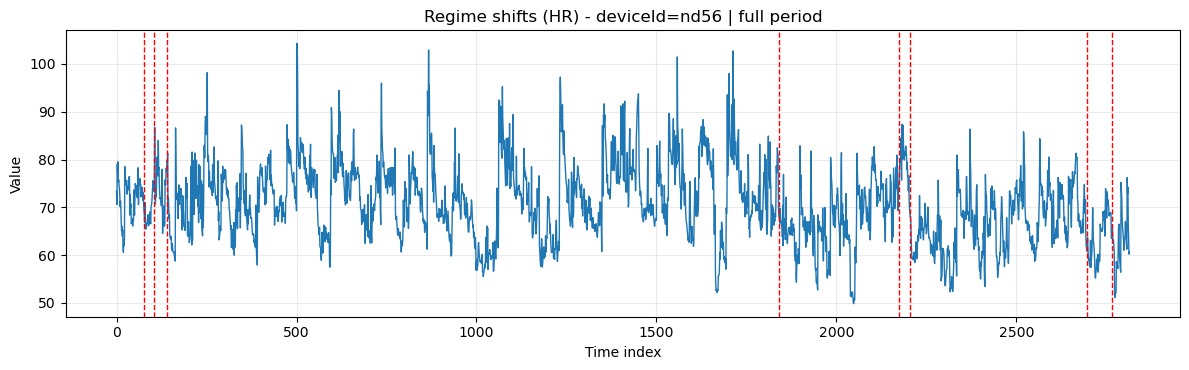

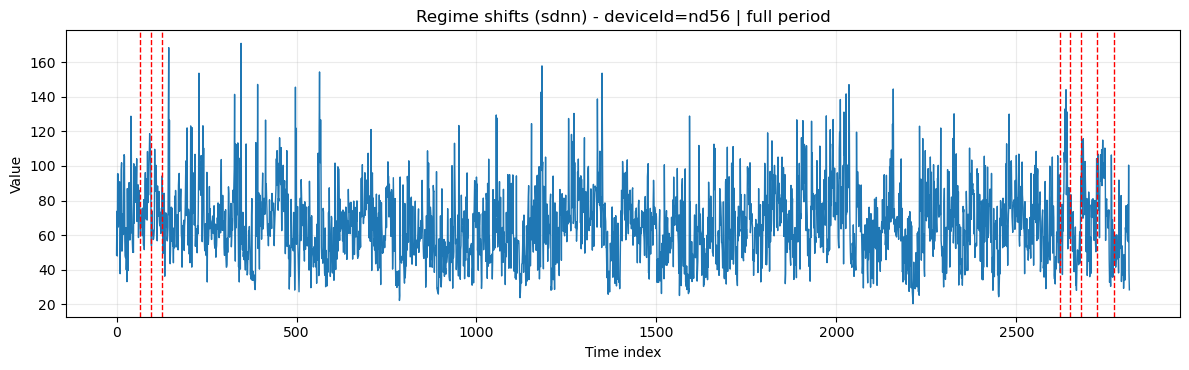

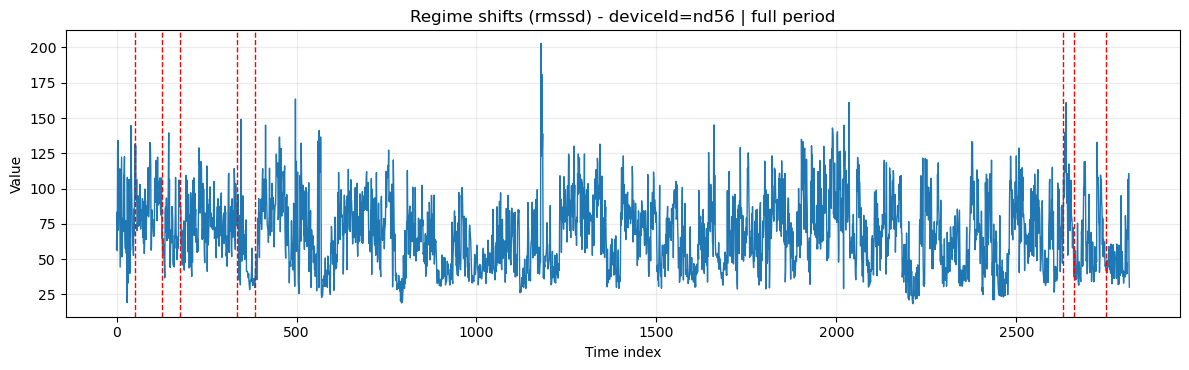

In [11]:
metrics = ["HR", "sdnn", "rmssd"]
baseline_n = 492

results = []
series_cache = {}

for metric in metrics:
    for device_id, grp in sensor_hrv_df.groupby("deviceId", dropna=True):
        s_full = (
            grp.sort_values("ts_start")[metric]
            .pipe(pd.to_numeric, errors="coerce")
            .dropna()
            .reset_index(drop=True)
        )
        s_base = s_full.iloc[:baseline_n]

        kpss_full = kpss_level_test(s_full, alpha=0.05)
        kpss_base = kpss_level_test(s_base, alpha=0.05)

        cps_full = divisive_change_points(
            s_full,
            alpha=0.05,
            min_size=30,
            n_perm=120,
            step=5,
            max_cps=8,
            seed=42,
        )
        cps_base = divisive_change_points(
            s_base,
            alpha=0.05,
            min_size=20,
            n_perm=120,
            step=3,
            max_cps=6,
            seed=42,
        )

        results.append(
            {
                "metric": metric,
                "deviceId": device_id,
                "n_full": int(kpss_full["n"]),
                "kpss_full_p": kpss_full["kpss_p"],
                "kpss_full_reject_stationarity": kpss_full["reject_stationarity"],
                "n_baseline": int(kpss_base["n"]),
                "kpss_baseline_p": kpss_base["kpss_p"],
                "kpss_baseline_reject_stationarity": kpss_base["reject_stationarity"],
                "n_regime_shifts_full": len(cps_full),
                "n_regime_shifts_baseline": len(cps_base),
            }
        )

        series_cache[(metric, device_id)] = (s_full, cps_full)

regime_shift_summary_df = pd.DataFrame(results)

for metric in metrics:
    mdf = regime_shift_summary_df[regime_shift_summary_df["metric"] == metric].copy()

    print(f"Regime-shift summary ({metric})")
    display(
        mdf.sort_values(["n_regime_shifts_full", "kpss_full_p"], ascending=[False, True])[
            [
                "deviceId",
                "n_full",
                "kpss_full_p",
                "kpss_full_reject_stationarity",
                "n_regime_shifts_full",
                "n_baseline",
                "kpss_baseline_p",
                "kpss_baseline_reject_stationarity",
                "n_regime_shifts_baseline",
            ]
        ].head(12)
    )

    print(
        "KPSS non-stationary (full):",
        int(mdf["kpss_full_reject_stationarity"].sum()),
        "/",
        int(mdf.shape[0]),
    )
    print(
        "KPSS non-stationary (baseline):",
        int(mdf["kpss_baseline_reject_stationarity"].sum()),
        "/",
        int(mdf.shape[0]),
    )
    print(
        "Mean # regime shifts (full):",
        f"{mdf['n_regime_shifts_full'].mean():.2f}",
    )
    print(
        "Mean # regime shifts (baseline):",
        f"{mdf['n_regime_shifts_baseline'].mean():.2f}",
    )
    print()

# Visual example per metric: device with the largest number of full-period regime shifts
for metric in metrics:
    mdf = regime_shift_summary_df[regime_shift_summary_df["metric"] == metric]
    if mdf.empty:
        continue
    row = mdf.sort_values(["n_regime_shifts_full", "n_full"], ascending=[False, False]).iloc[0]
    did = row["deviceId"]
    s_full, cps_full = series_cache[(metric, did)]
    plot_regime_shifts(
        s_full,
        cps_full,
        title=f"Regime shifts ({metric}) - deviceId={did} | full period",
    )
